# 0. Load python's packages
We need:
1. Pandas (https://pandas.pydata.org/docs/user_guide/index.html)
2. Numpy (https://numpy.org/doc/stable/user/index.html)
3. Scipy.optimize (https://docs.scipy.org/doc/scipy/tutorial/optimize.html)
4. Matplotlib.pyplot (https://matplotlib.org/stable/users/index.html)

In [1]:
import pandas as pd
import numpy as np
import scipy.optimize as spo
import matplotlib.pyplot as plt

# 1. Data & files management - Pandas

<div class="alert alert-success">
<h3><i class="fa fa-edit"></i> Exercise </h3>
    
Let's apply what we have just learnt on some real data!

$\gamma$-ray spectrometry with sodium iodide ($NaI$) detector:
1. Open the .Spe files you have collected during the previous laboratories: background, $^{60}Co$, $Na$, $^{241}Am$, $Ba$, $^{137}Cs$.
3. Create a DataFrame with two series of data: the channel number & the number of counts in each channel
4. Normalise the count-yield by the measurement time to make the different measurements comparable

In [2]:
# Since we need to perform the same tasks for different data-set, it is convenient to create a function that carries out all the tasks required
def preliminaryAnalysis(filepath):
    # Open dataset
    n_initial_rows = 0
    with open(filepath, 'r') as f:
        lines = f.read().splitlines()
        for line in lines:
            if "    " in line[:4]:
                break
            else:
               n_initial_rows += 1 # in Python x += 1 is a short command for x = x + 1
    with open(filepath, 'r') as f:
        lines = f.read().splitlines()
        for i, line in enumerate(lines):
            if "$DATA:" == line:
                ch_str = lines[i+1]
                ch_str_list = ch_str.split(" ")
                ch_initial = float(ch_str_list[0])
                ch_final = float(ch_str_list[1])
                break
    n_rows_data = ch_final - ch_initial + 1
    dm = pd.read_csv(filepath, sep=" ", skiprows=n_initial_rows, nrows=n_rows_data, skipinitialspace=True, names=['N'])
    
    # Include a column with the channel number
    dm['ch'] = np.append(np.arange(ch_initial, ch_final, step=1), ch_final)

    # Normalise the count-yield by the measurement time --> count-rate
    mtime = 0
    with open(filepath, 'r') as f:
        # Retrieve information on measurement time from headers
        lines = f.read().splitlines()
        for i in range(len(lines)):
            if "$MEAS_TIM:" == lines[i]:
                mt_str = lines[i+1]
                mt_str = mt_str.split(" ")[0]
                mtime = float(mt_str) # s
                break
    dm['NR'] = dm['N'] / mtime
    return dm
# Open the different measurements
d_bg = preliminaryAnalysis("../data/background.Spe")
d_co = preliminaryAnalysis("../data/Co60_contact.Spe")
d_na = preliminaryAnalysis("../data/Na_setup.Spe")
d_am = preliminaryAnalysis("../data/Am_setup.Spe")
d_ba = preliminaryAnalysis("../data/Ba_setup.Spe")
d_cs = preliminaryAnalysis("../data/Cs_setup_FG0.5_AMP10_ST1.Spe")
    

# 2. Data visualisation - Matplotlib.pyplot

<div class="alert alert-success">
<h3><i class="fa fa-edit"></i> Exercise </h3>
    
Let's have a look on the $\gamma$-ray spectrometry data measured:
1. Plot the background.
2. Plot in different figures the spectra you have collected during the previous laboratories, including the background as a dashed line in each plot:$^{60}Co$, $Na$, $^{241}Am$, $Ba$, $^{137}Cs$.
3. Include the errorbars in at least one of the figure

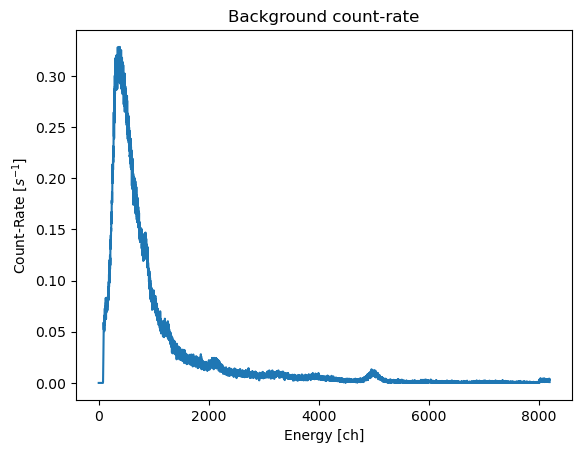

In [3]:
def make_axis():
    plt.xlabel("Energy [ch]")
    plt.ylabel(r"Count-Rate [$s^{-1}$]")
    return
# Background
plt.figure('bg')
plt.title("Background count-rate")
plt.plot(d_bg['ch'], d_bg['NR'])
make_axis()

(0.0, 500.0)

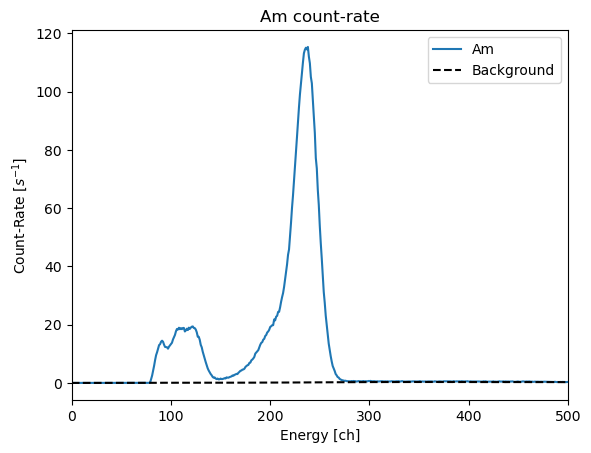

In [4]:
# Measurements
def singleplot(d, name, errorbar=False):
    """
    Estimate uncertainty: radiation measurements follows Poisson statistics
    -> if we carry out many different measurements, the number of counts in each channel will distribute as a Poisson distribution
    -> by having this knowledge, even just with one measurement we can estimate the uncertainty of the number of counts as u=sqrt(N)
    """
    uN = np.sqrt(d['N'])
    """
    Now we need to propagate the uncertainty of N to NR (count-rate)
    -> assuming that the measurement time has no uncertainty (which is questionable however), N and NR have the same relative uncertainty
    """
    uNR = (uN / d['N']) * d['NR']
    
    plt.figure(name)
    plt.title(name + " count-rate")
    if errorbar:
        plt.errorbar(d['ch'], d['NR'], yerr=uNR, label=name)
    else:
        plt.plot(d['ch'], d['NR'], label=name)
    plt.plot(d_bg['ch'], d_bg['NR'], linestyle='--', color='black', label="Background")
    make_axis()
    plt.legend()
    return
singleplot(d_am, "Am")
plt.xlim(0,500)

(0.0, 2000.0)

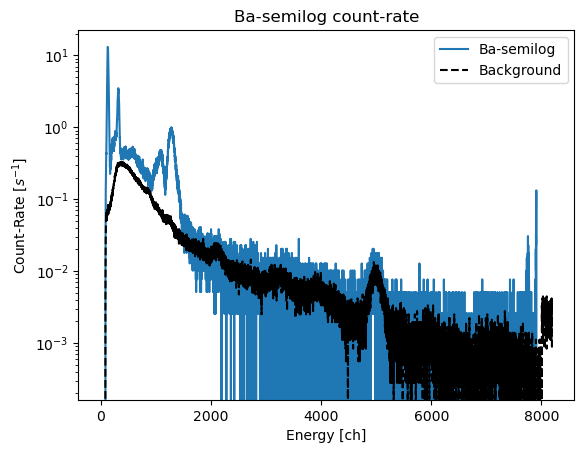

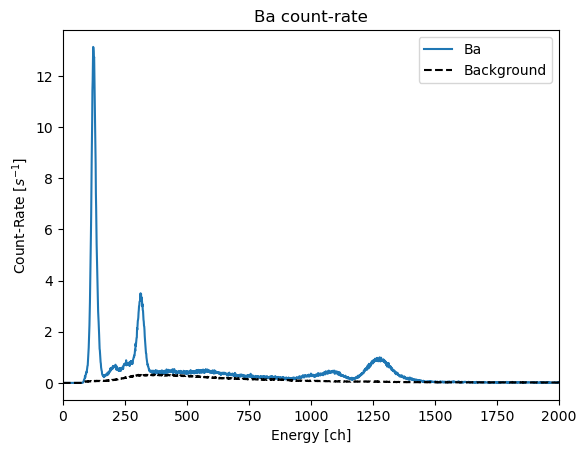

In [5]:
singleplot(d_ba, "Ba-semilog")
plt.yscale('log')
singleplot(d_ba, "Ba")
plt.xlim(0,2000)

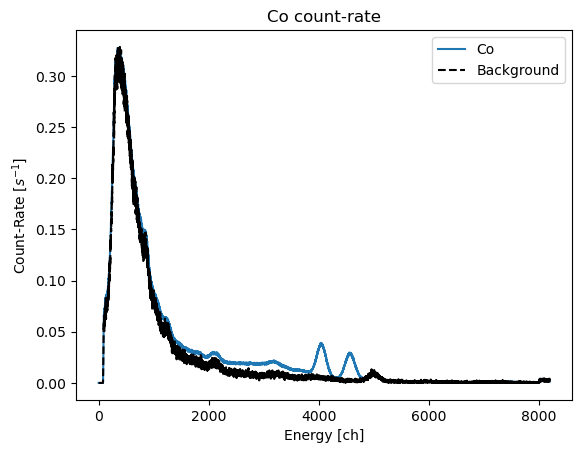

In [6]:
singleplot(d_co, "Co")

(0.0, 3000.0)

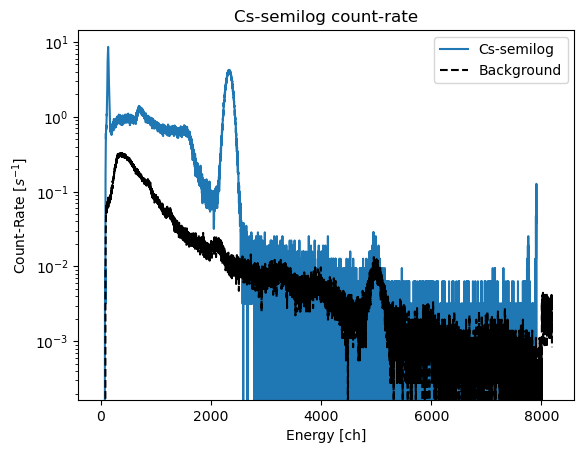

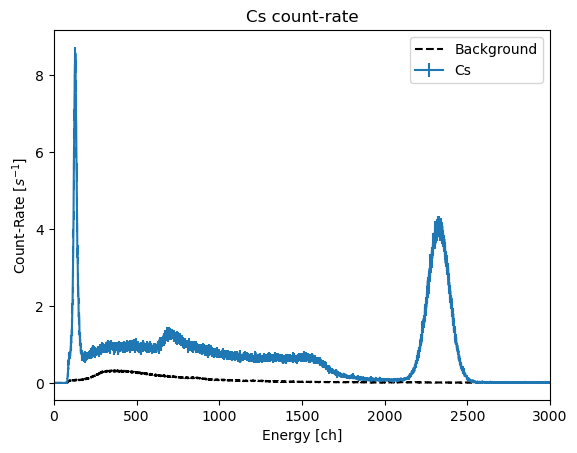

In [7]:
singleplot(d_cs, "Cs-semilog")
plt.yscale('log')
singleplot(d_cs, "Cs", errorbar=True)
plt.xlim(0,3000)

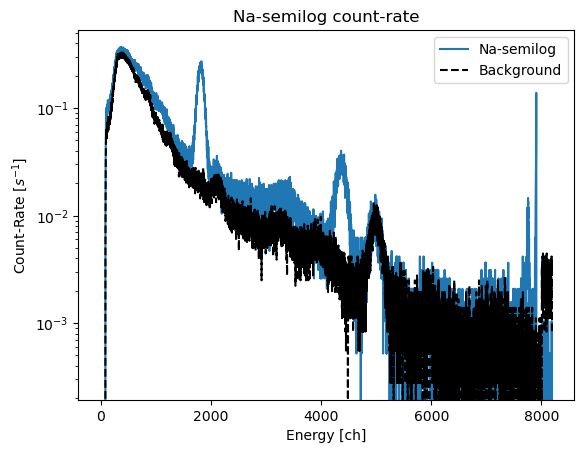

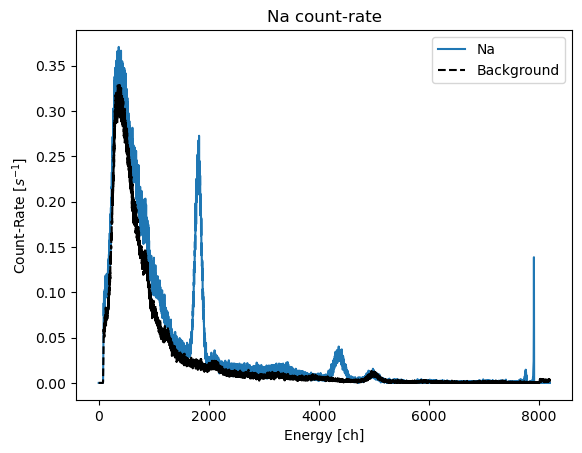

In [8]:
singleplot(d_na, "Na-semilog")
plt.yscale('log')
singleplot(d_na, "Na")

# 3. Data analysis - Numpy & Scipy

<h3><i class="fa fa-eye"></i> IMPORTANT! </h3>

<h4>Even though they are not strictly necessary, it is very important to give an initial guess and/or a range of values where to look for the parameters, in order to obtain a good fit! </h4>

<div class="alert alert-success">
<h3><i class="fa fa-edit"></i> Exercise </h3>
    
Let's do some basic analysis on the $\gamma$-ray spectrometry data measured. For the different data measured ($^{60}Co$, $Na$, $^{241}Am$, $Ba$, $^{137}Cs$):
1. Subtract the background and plot the cleaned spectra.
2. Visually identify the peaks and fit the appropriate subset of data with a Gaussian function.
3. Plot the cleaned spectrum and the fitted peaks to check the fitting procedure worked well.
4. Retrieve and print the peaks position in channels
5. Assigning to each peak its nominal energy value, plot the calibration curve

<h4><i class="fa fa-lightbulb"></i> Suggestion </h4>
Simultaneously analysing all measurements can be overwhelming. Do the exercise for one of the measurement (e.g. the $^{60}Co$ dataset) and execute it. Once you becomes practical with the analysis, you can re-iterate it on the other dataset by simply changing the data-frame analysed and the fit intervals.

In [9]:
## Co-60 analysis
# 1) subtract the background
d_co['NRclean'] = d_co['NR'] - d_bg['NR']
print(d_co['NRclean'])

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
8187   -0.000494
8188   -0.000760
8189    0.001575
8190    0.000613
8191    0.000543
Name: NRclean, Length: 8192, dtype: float64


In [10]:
# To avoid un-physical negative values due to statistical uncertainties, set to 0 the possible negative values
nrclean = d_co['NRclean'].to_numpy()
for i, inrc in enumerate(nrclean):
    if inrc < 0:
        nrclean[i] = 0
# Shortcut using logic-operation
nrclean = d_co['NRclean'].to_numpy()
nrclean *= (nrclean >= 0) 
d_co['NRclean'] = nrclean
# Shortcut using Pandas Dataframe operations
d_co['NRclean'] = d_co['NR'] - d_bg['NR']
d_co.loc[d_co['NRclean'] < 0, 'NRclean'] = 0
print(d_co['NRclean'])

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
8187    0.000000
8188    0.000000
8189    0.001575
8190    0.000613
8191    0.000543
Name: NRclean, Length: 8192, dtype: float64


(3500.0, 5000.0)

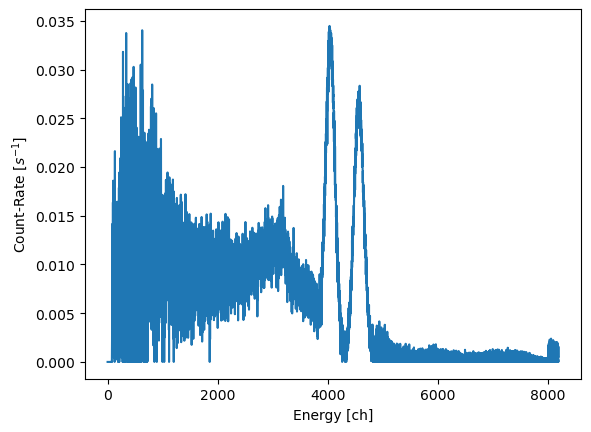

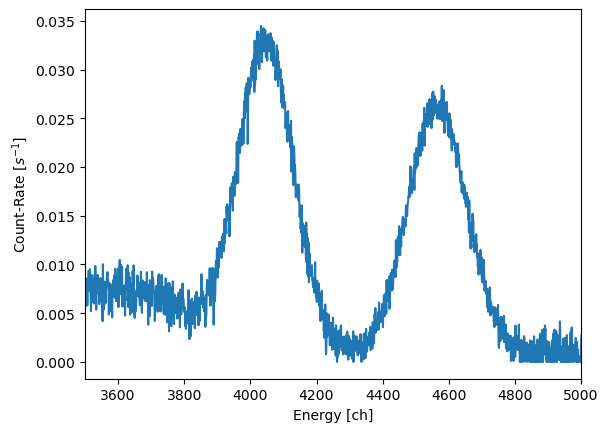

In [11]:
# 2 Visually identify the peaks: we can "zoom" on each peak
plt.figure()
plt.plot(d_co['ch'], d_co['NRclean'])
make_axis()
plt.figure()
plt.plot(d_co['ch'], d_co['NRclean'])
make_axis()
plt.xlim(3500,5000)

In [12]:
# 2) Fit the peaks with a Gaussian function
def gauss(x, mu, sigma, weight):
    return weight * ( 1 / (sigma * np.sqrt(2*np.pi)) ) * np.exp(- 1/2 * ((x - mu) / sigma)**2)

x = d_co['ch'].to_numpy()
y = d_co['NRclean'].to_numpy()

# Peak 1
mu = 4000
sig = 200
w = 0.035 * sig * np.sqrt(2*np.pi)
""" 
For an appropriate fit of each peak, we need to fit only a limited subset of the measurement data
--> big enough to encompass the peak but not so big to include other features!
"""
xmin1 = 3900
xmax1 = 4200
y1 = y[(x > xmin1) & (x < xmax1)]
x1 = x[(x > xmin1) & (x < xmax1)]
k_p1, _ = spo.curve_fit(gauss, x1, y1, p0=np.array([mu,sig,w]), bounds = (np.zeros(3), np.zeros(3) + np.inf))
# Peak 2
mu = 4600
sig = 300
w = 0.025 * sig * np.sqrt(2*np.pi)
xmin2 = 4400
xmax2 = 4800
y2 = y[(x > xmin2) & (x < xmax2)]
x2 = x[(x > xmin2) & (x < xmax2)]
k_p2, _ = spo.curve_fit(gauss, x2, y2, p0=np.array([mu,sig,w]), bounds = (np.zeros(3), np.zeros(3) + np.inf))

(3500.0, 5000.0)

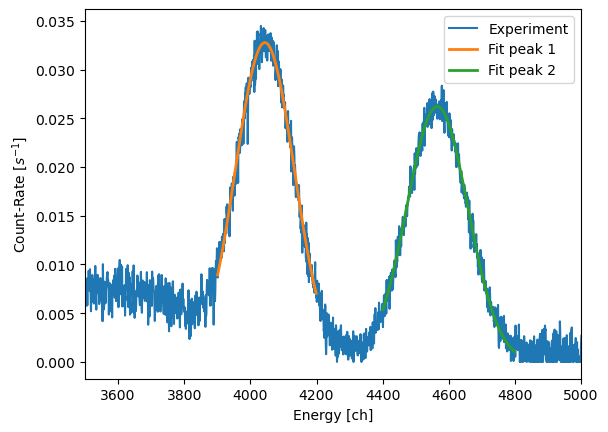

In [13]:
# 3) Plot spectrum and fitted peaks
plt.figure()
plt.plot(d_co['ch'], d_co['NRclean'], label="Experiment")
plt.plot(x1, gauss(x1, *k_p1), linewidth=2, label="Fit peak 1")
plt.plot(x2, gauss(x2, *k_p2), linewidth=2, label="Fit peak 2")
make_axis()
plt.legend()
plt.xlim(3500,5000)

In [14]:
# 4) Retrieve and print peaks position
# The mean value of the fitted Gaussian curve (the mu) is conventionally taken as representative of the peak position
peaks_co = np.array([k_p1[0], k_p2[0]])
print(str("The measured position of the Co-60 peaks are:\n  1st peak: %.3e channels\n  2nd peak: %.3e channels" % (peaks_co[0],peaks_co[1])))

The measured position of the Co-60 peaks are:
  1st peak: 4.044e+03 channels
  2nd peak: 4.565e+03 channels


Text(0.5, 0, 'Energy [keV]')

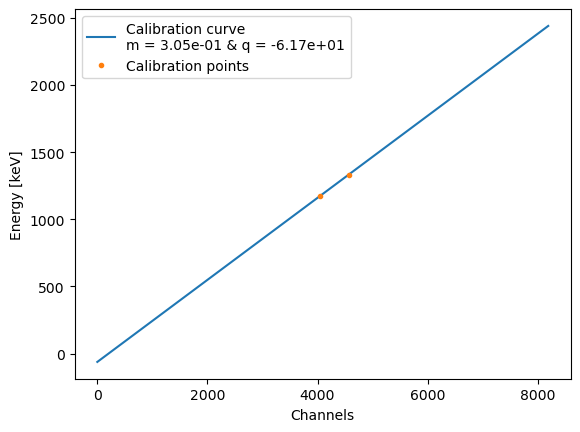

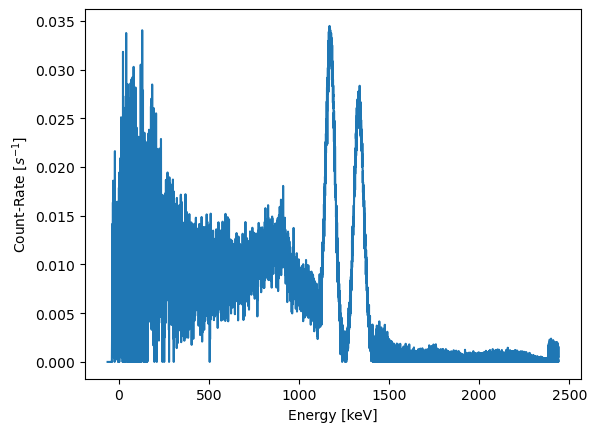

In [15]:
# 5) Assign each peak its nominal energy value and plot calibration curve
"""
The energy of the two Co-60's gamma emission are: 1173.23 keV & 1332.49 keV [IAEA]
"""
E1 = 1173.23
E2 = 1332.49
E_peaks = np.array([E1, E2])
ch_peaks = peaks_co.copy()
# Assuming a linear calibration curve E = m*CH + q
# --> 2 peaks, only one possible line
m = (E_peaks[1] - E_peaks[0]) / (peaks_co[1] - peaks_co[0])
q = E_peaks[0] - m * peaks_co[0]
d_co['e'] = d_co['ch'] * m + q

# Plot calibration curve
plt.figure()
plt.plot(d_co['ch'], d_co['e'], label = "Calibration curve\n" + str("m = %.2e & q = %.2e" % (m, q)))
plt.plot(peaks_co, E_peaks, marker='.', linestyle='none', label="Calibration points")
plt.xlabel("Channels")
plt.ylabel("Energy [keV]")
plt.legend()

# Plot calibrated spectrum
plt.figure()
plt.plot(d_co['e'], d_co['NRclean'])
make_axis()
plt.xlabel("Energy [keV]")

<h4>Assuming a linear calibration curve </h4>

$E = m\cdot CH + q$
    
- If only 1 peak <i class="fa fa-arrow-right"></i> it reduces to $E = m\cdot CH$ <i class="fa fa-arrow-right"></i> $m = \frac{E}{peak}$ & $q=0$
- If 2 peaks <i class="fa fa-arrow-right"></i> only one possible line by two points:
- If **more than 2 peaks** <i class="fa fa-arrow-right"></i> perform a linear fit or **fit with any function that is more appropriate in that specific situation!**

<h4><i class="fa fa-eye"></i> Important consideration</h4>

In a situation like this, where the same measurement system is used to measure many different sources, the best calibration curve is obtained by considering all peaks from all measurements!

(1500.0, 5000.0)

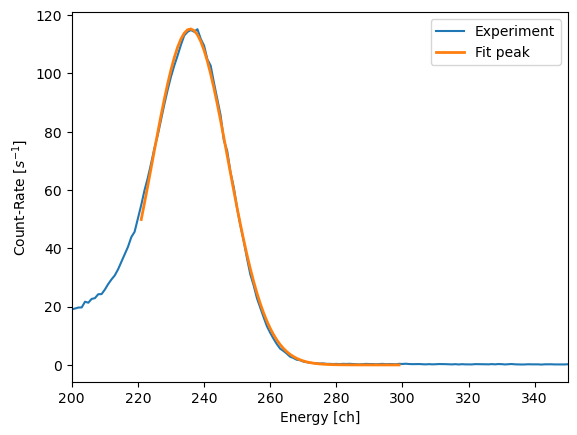

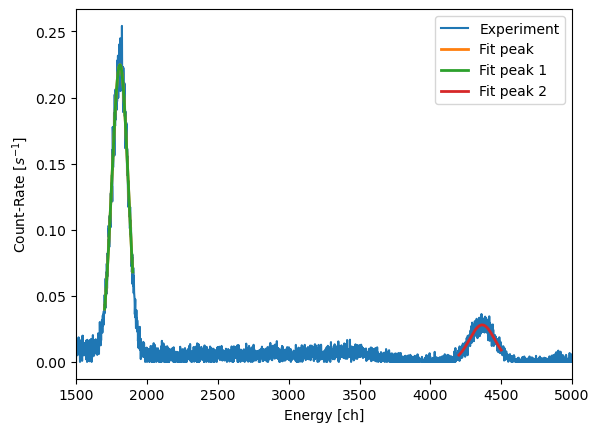

In [16]:
# Am
d_am['NRclean'] = d_am['NR'] - d_bg['NR']
d_am['NRclean'] = d_am['NR'] - d_bg['NR']
d_am.loc[d_am['NRclean'] < 0, 'NRclean'] = 0
# Peak
x = d_am['ch'].to_numpy()
y = d_am['NRclean'].to_numpy()
mu = 250
sig = 50
w = 120 * sig * np.sqrt(2*np.pi)
xmin1 = 220
xmax1 = 300
y1 = y[(x > xmin1) & (x < xmax1)]
x1 = x[(x > xmin1) & (x < xmax1)]
k_p1, _ = spo.curve_fit(gauss, x1, y1, p0=np.array([mu,sig,w]), bounds = (np.zeros(3), np.zeros(3) + np.inf))

E_peaks = np.append(E_peaks, 59.54) # IAEA 59.54 keV
ch_peaks = np.append(ch_peaks, k_p1[0])

plt.figure()
plt.plot(d_am['ch'], d_am['NRclean'], label="Experiment")
plt.plot(x1, gauss(x1, *k_p1), linewidth=2, label="Fit peak")
make_axis()
plt.legend()
plt.xlim(200,350)
# Na
d_na['NRclean'] = d_na['NR'] - d_bg['NR']
d_na['NRclean'] = d_na['NR'] - d_bg['NR']
d_na.loc[d_na['NRclean'] < 0, 'NRclean'] = 0
# Peak 1
x = d_na['ch'].to_numpy()
y = d_na['NRclean'].to_numpy()
mu = 1800
sig = 100
w = 0.2 * sig * np.sqrt(2*np.pi)
xmin1 = 1700
xmax1 = 1900
y1 = y[(x > xmin1) & (x < xmax1)]
x1 = x[(x > xmin1) & (x < xmax1)]
k_p1, _ = spo.curve_fit(gauss, x1, y1, p0=np.array([mu,sig,w]), bounds = (np.zeros(3), np.zeros(3) + np.inf))
# Peak 2
mu = 4350
sig = 200
w = 0.05 * sig * np.sqrt(2*np.pi)
xmin2 = 4200
xmax2 = 4500
y2 = y[(x > xmin2) & (x < xmax2)]
x2 = x[(x > xmin2) & (x < xmax2)]
k_p2, _ = spo.curve_fit(gauss, x2, y2, p0=np.array([mu,sig,w]), bounds = (np.zeros(3), np.zeros(3) + np.inf))

E_peaks = np.append(E_peaks, np.array([511, 1274.54])) # IAEA gamma emission @ 1274.54 keV and annihilation gamma @ 511 keV
ch_peaks = np.append(ch_peaks, np.array([k_p1[0], k_p2[0]]))

plt.figure()
plt.plot(d_na['ch'], d_na['NRclean'], label="Experiment")
plt.plot(x1, gauss(x1, *k_p1), linewidth=2, label="Fit peak")
plt.plot(x1, gauss(x1, *k_p1), linewidth=2, label="Fit peak 1")
plt.plot(x2, gauss(x2, *k_p2), linewidth=2, label="Fit peak 2")
make_axis()
plt.legend()
plt.xlim(1500,5000)

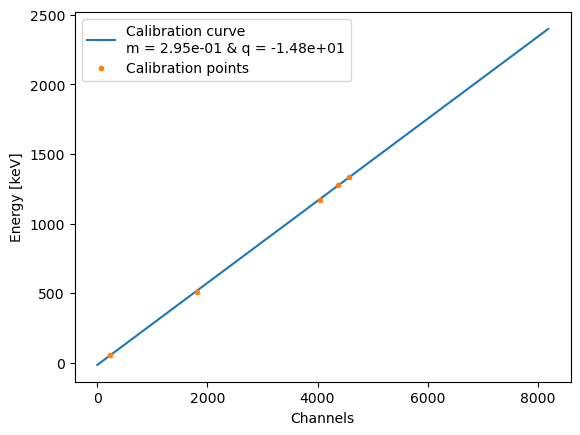

In [17]:
# Overall calibration
def linfun(x, m, q):
    return x * m + q
calib_k, _ = spo.curve_fit(linfun, ch_peaks, E_peaks, p0=np.array([m,q]), bounds=(np.array([0,-np.inf]), np.zeros(2) + np.inf))
plt.figure()
plt.plot(d_bg['ch'], linfun(d_bg['ch'], *calib_k), label = "Calibration curve\n" + str("m = %.2e & q = %.2e" % (calib_k[0], calib_k[1])))
plt.plot(ch_peaks, E_peaks, marker='.', linestyle = 'none', label = "Calibration points")
plt.xlabel("Channels")
plt.ylabel("Energy [keV]")
plt.legend()